### 7. COHORT ANALYSIS & INSIGHTS

**Goal:**  
Build cohort-based retention and revenue analysis with clear visualizations and actionable business insights.

**Approach:**
- Use cohort tables prepared in SQL
- Perform retention, revenue, and AOV analysis in Python
- Apply customer segmentation (High vs Regular spenders)

In [2]:
# Loading necessary libraries and data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from local_config import *

engine = create_engine(
    f'postgresql://{db_user}:{db_password}@{db_host}:{db_port}/{db_name}'
)

cohort_base = pd.read_sql("SELECT * FROM analytics.cohort_analysis_base", engine)

In [3]:
# Data Preparation for Cohort Analysis
cohort_base['order_month'] = pd.to_datetime(cohort_base['order_month'])
cohort_base['cohort_month'] = pd.to_datetime(cohort_base['cohort_month'])

cohort_base['month_number'] = (
    (cohort_base['order_month'].dt.year * 12 + cohort_base['order_month'].dt.month) -
    (cohort_base['cohort_month'].dt.year * 12 + cohort_base['cohort_month'].dt.month)
)

### Customer Retention

In [4]:
# Create a cohort matrix for customer retention
cohort_matrix = cohort_base.pivot_table(
    index='cohort_month',
    columns='month_number',
    values='customer_id',
    aggfunc='nunique'
).fillna(0)

# Convert index to datetime and then to period for better visualization
cohort_matrix.index = pd.to_datetime(cohort_matrix.index).to_period('M')

# Calculate retention rates
cohort_size = cohort_matrix.iloc[:, 0]
retention_rate = cohort_matrix.divide(cohort_size, axis=0)


In [5]:
cohort_size

cohort_month
2010-12    948.0
2011-01    421.0
2011-02    380.0
2011-03    440.0
2011-04    299.0
2011-05    279.0
2011-06    235.0
2011-07    191.0
2011-08    167.0
2011-09    298.0
2011-10    352.0
2011-11    321.0
2011-12     41.0
Freq: M, Name: 0, dtype: float64

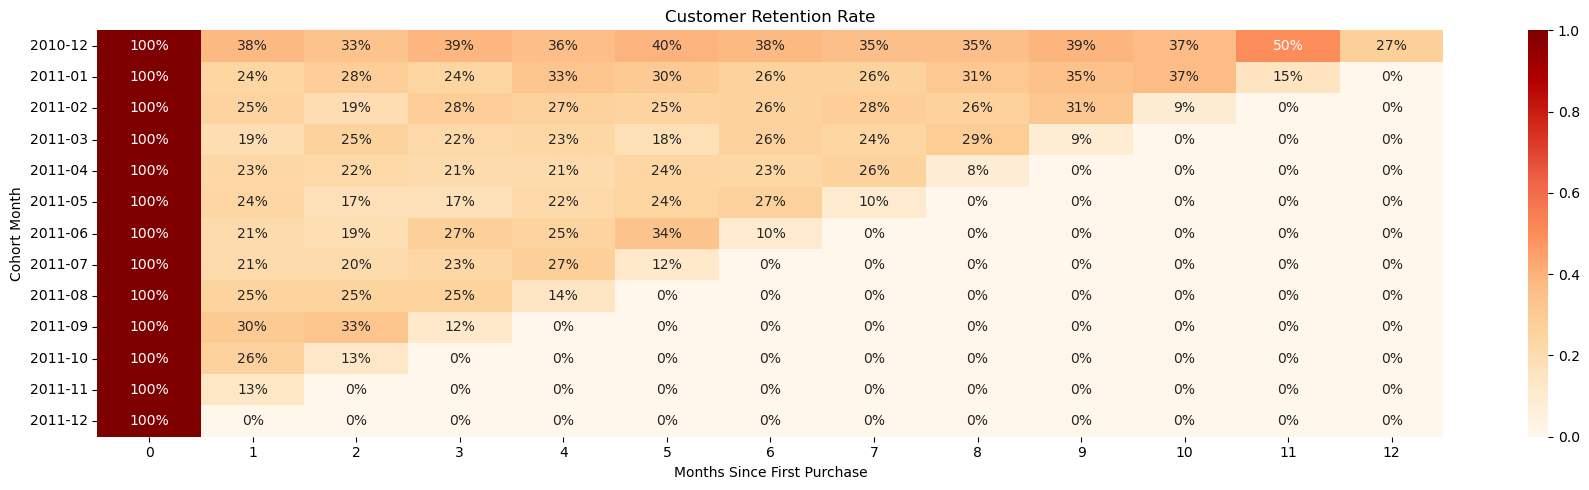

In [6]:
# Visualize retention rates
plt.figure(figsize=(18, 5))
sns.heatmap(retention_rate, cmap='OrRd', vmin=0, vmax=1, annot=True, fmt='.0%')
plt.title('Customer Retention Rate')
plt.xlabel('Months Since First Purchase')
plt.ylabel('Cohort Month')
plt.tight_layout()
plt.show()

### Insights

**1. Strong initial drop in retention**
- Month 1 retention across cohorts: ~20–30%
- Indicates that most users are one-time buyers

**Insight:**  
The majority of customers do not return after their first purchase, suggesting weak early engagement.


**2. Retention stabilizes after Month 2–3**
- Later retention fluctuates around ~20–35%

**Insight:**  
A small group of users forms a stable, loyal base, but there is no strong growth in engagement over time.


**3. No improvement in newer cohorts**
- Early cohort (2010-12): ~38% Month 1 retention
- Later cohorts: mostly ~20–25%

**Insight:**  
Customer retention has not improved over time, indicating no major gains in acquisition quality or retention strategy.

---
### Revenue Retention

In [7]:
# Create a cohort matrix for revenue retention
revenue = cohort_base.pivot_table(
    index='cohort_month',
    columns='month_number',
    values='order_revenue',
    aggfunc='sum'
).fillna(0)

# Convert index to datetime and then to period for better visualization
revenue.index = pd.to_datetime(revenue.index).to_period('M')

# Calculate revenue retention rates 
revenue_retention = revenue.divide(revenue.iloc[:, 0], axis=0)

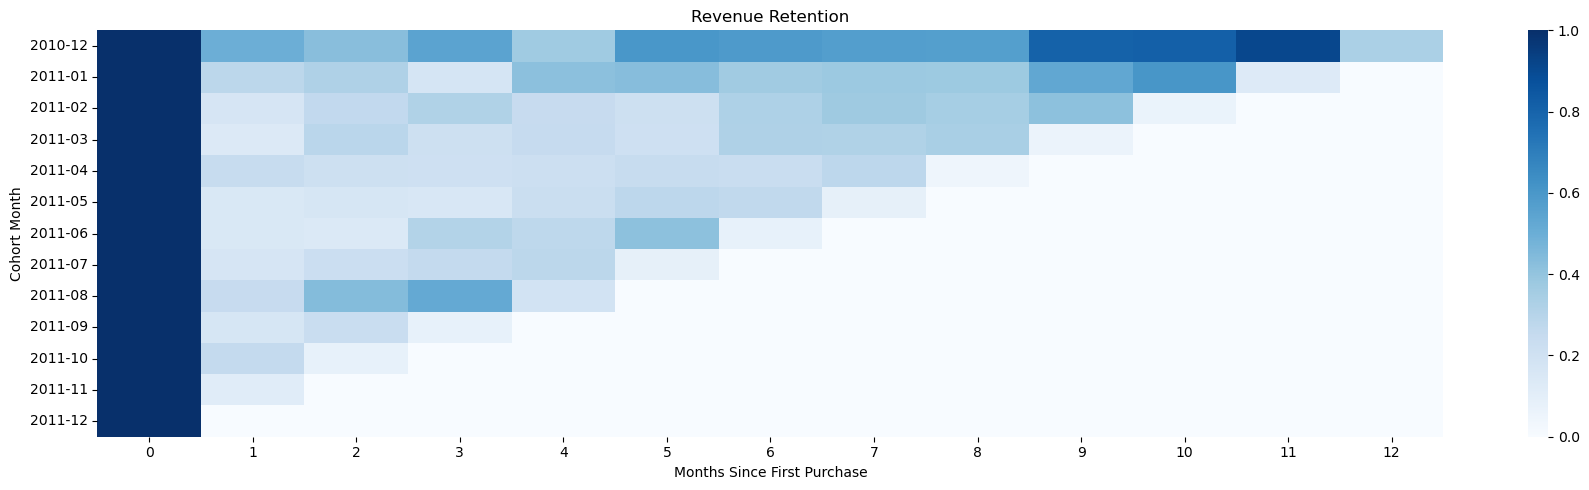

In [8]:
# Visualize revenue retention rates
plt.figure(figsize=(18, 5))
sns.heatmap(revenue_retention, cmap='Blues', vmin=0, vmax=1)
plt.title('Revenue Retention')
plt.xlabel('Months Since First Purchase')
plt.ylabel('Cohort Month')
plt.tight_layout()
plt.show()

### Insights

**1. Revenue retention is higher than customer retention**
- Returning users generate disproportionately more revenue

**Insight:**  
High-value customers contribute more revenue, even if overall retention is low.


**2. Non-linear revenue behavior**
- Some cohorts show spikes in later months

**Insight:**  
Revenue is driven by a small number of high-value users (“whales”) making large or infrequent purchases.


**3. Revenue concentrated in early lifecycle**
- Most revenue generated in Month 0–3

**Insight:**  
The business relies heavily on early monetization with limited long-term revenue consistency.

---
### AOV (Average Order Value)

In [9]:
# Create a cohort matrix for average order value (AOV)
cohort_aov = cohort_base.pivot_table(
    index='cohort_month',
    columns='month_number',
     values='order_revenue',
        aggfunc='mean').round(2).fillna(0)

# Convert index to datetime and then to period for better visualization
cohort_aov.index = pd.to_datetime(cohort_aov.index.get_level_values('cohort_month')).to_period('M')


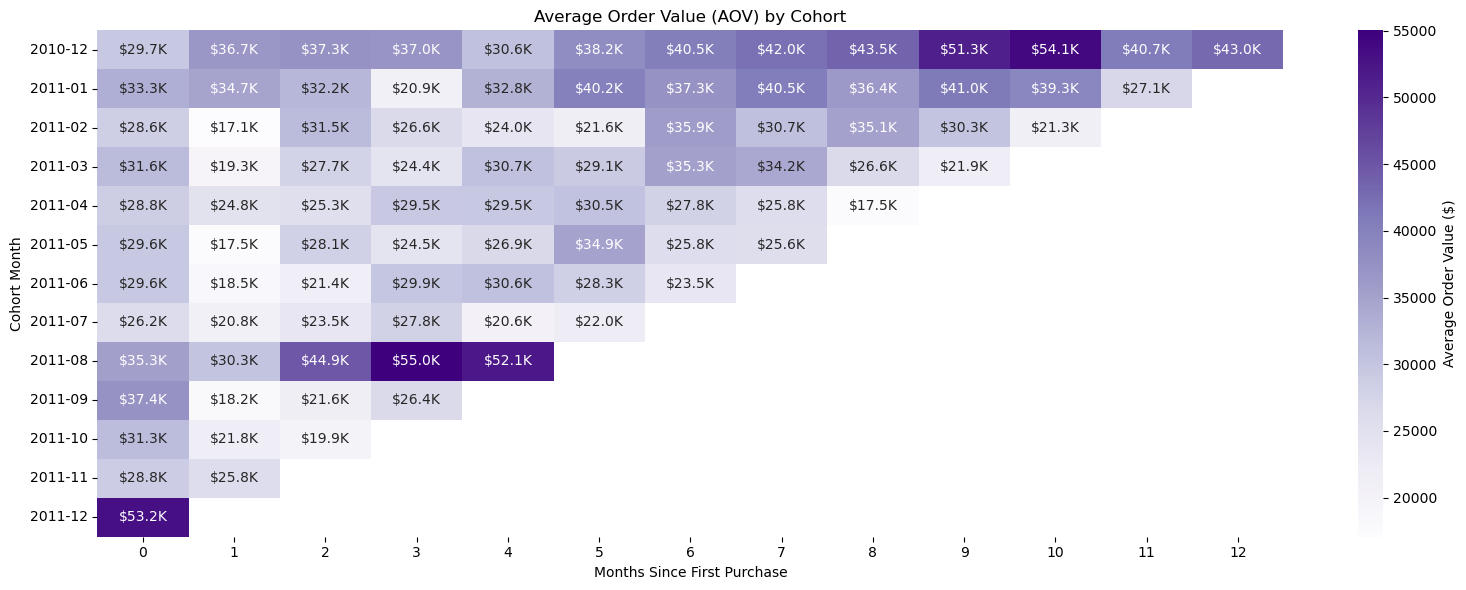

In [10]:
# Visualize AOV by cohort
plt.figure(figsize=(16, 6))

cohort_aov_clean = cohort_aov.replace(0, np.nan)

annot_data = cohort_aov_clean.apply(lambda x: x.map(lambda y: f"${y/1000:.1f}K" if pd.notnull(y) else ""))

sns.heatmap(
    cohort_aov_clean,
    annot=annot_data,
    fmt='',
    cmap='Purples',
    cbar_kws={'label': 'Average Order Value ($)'}
)

plt.title('Average Order Value (AOV) by Cohort')
plt.xlabel('Months Since First Purchase')
plt.ylabel('Cohort Month')

plt.grid(False)

plt.tight_layout()
plt.show()

### Insights

**1. AOV increases over time**
- Retained users tend to spend more

**Insight:**  
Loyal customers become more valuable over time.


**2. High variability across cohorts**

**Insight:**  
Purchase behavior varies significantly due to seasonality, promotions, or customer mix.


**3. Presence of outliers**

**Insight:**  
A small number of high-value transactions significantly impact AOV.

---

### Revenue Segmentation (High - Value vs Regular)

**Goal:**  
Segment customers based on total revenue:
- High-Value: Top 30%
- Regular: Bottom 70%

**Purpose:**  
Understand differences in retention, behavior, and value between segments.

In [11]:
# Calculate total revenue per customer  to identify high-value customers for insights
revenue_by_customer = cohort_base.groupby('customer_id')['order_revenue'].sum()

# Calculate the 70th percentile of revenue per customer
percentile_revenue_70 = revenue_by_customer.quantile(0.7)

# Classify customers into segments based on their total revenue
cohort_base['customer_segment'] = np.where(
    cohort_base['customer_id'].isin(revenue_by_customer[revenue_by_customer >= percentile_revenue_70].index),
    'High-Value',
    'Regular'
)

#### Revenue Concentration Analysis

To better understand revenue distribution, we compare the share of customers vs share of revenue by segment.


In [12]:
revenue_by_segment = (
    cohort_base
    .groupby('customer_segment')
    .agg(
        segment_customers_nmb=('customer_id', 'nunique'),
        segment_revenue=('order_revenue', 'sum')
    )
    .reset_index()
)

# totals
total_revenue = revenue_by_segment['segment_revenue'].sum()
total_customers = revenue_by_segment['segment_customers_nmb'].sum()

# shares
revenue_by_segment = revenue_by_segment.assign(
    segment_revenue_share=lambda df: (df['segment_revenue'] / total_revenue * 100).round(2),
    segment_customer_share=lambda df: (df['segment_customers_nmb'] / total_customers * 100).round(2)
)

revenue_by_segment

,customer_segment,segment_customers_nmb,segment_revenue,segment_revenue_share,segment_customer_share
0,High-Value,1312,632181249.0,82.54,30.01
1,Regular,3060,133739609.0,17.46,69.99


**Key Finding:**
- Top 30% of customers generate ~83% of total revenue
- Bottom 70% contribute only ~17%

**Insight:**  
Revenue is highly concentrated within a small subset of users, indicating a strong Pareto-like distribution.

In [13]:
#---------------------------
#  High-Value spenders 
#---------------------------

# Filter cohort_base for high-value customers
cohort_base_high_value = cohort_base[cohort_base['customer_segment'] == 'High-Value']

In [14]:
# Create a cohort matrix for high-value customers
cohort_high_value = cohort_base_high_value.pivot_table(
    index='cohort_month',
    columns='month_number',
    values='customer_id',
    aggfunc='nunique'
).fillna(0)

# Convert index to datetime and then to period for better visualization
cohort_high_value.index = pd.to_datetime(cohort_high_value.index.get_level_values('cohort_month')).to_period('M')
# Calculate retention rates for high-value customers
cohort_high_value_size = cohort_high_value.iloc[:,0]
high_value_retention = cohort_high_value.divide(cohort_high_value_size, axis=0)

In [15]:
#---------------------------
#  Regular spenders 
#---------------------------

# Filter cohort_base for regular customers
cohort_base_regular_value = cohort_base[cohort_base['customer_segment'] == 'Regular']

In [16]:
# Create a cohort matrix for regular customers
cohort_regular = cohort_base_regular_value.pivot_table(
    index='cohort_month',
    columns='month_number',
    values='customer_id',
    aggfunc='nunique'
).fillna(0)

# Convert index to datetime and then to period for better visualization
cohort_regular.index = pd.to_datetime(cohort_regular.index.get_level_values('cohort_month')).to_period('M')

# Calculate retention rates for regular customers
cohort_regular_size = cohort_regular.iloc[:,0]  
regular_retention = cohort_regular.divide(cohort_regular_size, axis=0)

# Calculate the difference in retention rates between high-value and regular customers
high_value_retention_minus_regular = high_value_retention - regular_retention


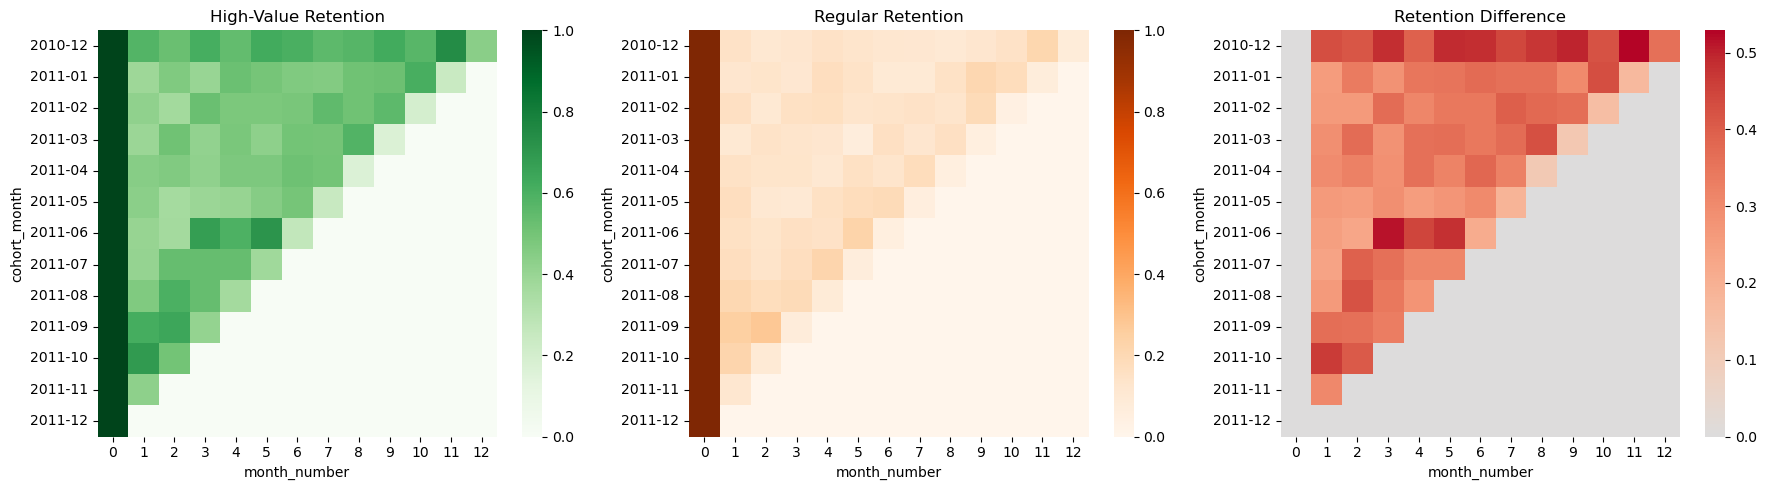

In [17]:
#---------------------------
#  Retention Comparison
#---------------------------

# Visualize retention rates for high-value and regular customers, and their difference
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(high_value_retention, cmap='Greens', ax=ax[0])
ax[0].set_title('High-Value Retention')

sns.heatmap(regular_retention, cmap='Oranges', ax=ax[1])
ax[1].set_title('Regular Retention')

sns.heatmap(high_value_retention_minus_regular, cmap='coolwarm', center=0, ax=ax[2])
ax[2].set_title('Retention Difference')

plt.tight_layout()
plt.show()

### Insights

- High-value customers have 2–4x higher retention than regular customers
- Retention gap remains consistently large across all cohorts
- Regular customers churn quickly and rarely become long-term users
- High-value customers form a loyal and stable core segment
- The first 1–3 months are critical for customer retention

**Insight:**  
Customer value strongly correlates with retention and long-term engagement.

In [18]:
#---------------------------
# AOV in high vs low spenders
#---------------------------

# Calculate AOV by customer segment
AOV_by_customer_segment = cohort_base.groupby(['cohort_month', 'customer_segment'])['order_revenue'].mean().unstack()

# Calculate the percentage difference in AOV between high-value and regular customers
AOV_by_customer_segment['AOV Difference %'] = ((AOV_by_customer_segment['High-Value'] - AOV_by_customer_segment['Regular'])/AOV_by_customer_segment['Regular']*100).round(2)

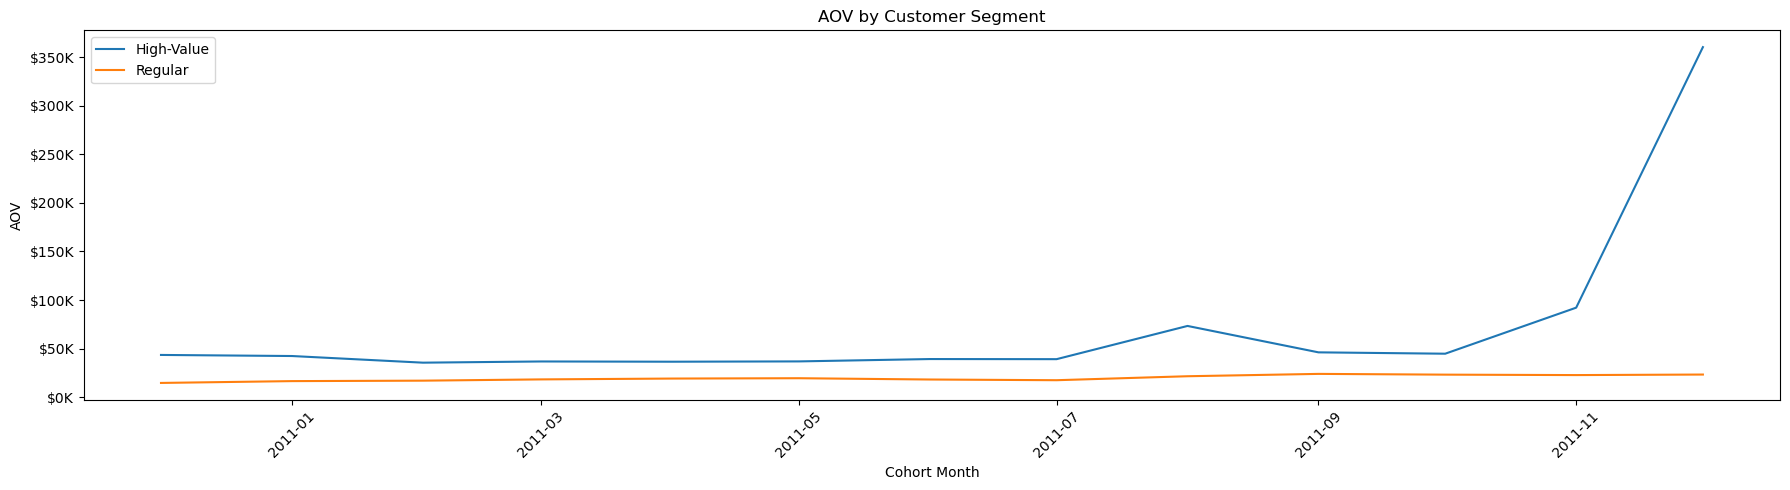

In [19]:
# Visualize AOV by customer segment
plt.figure(figsize=(18, 5))

data_plot = AOV_by_customer_segment.reset_index()

sns.lineplot(data=data_plot, x='cohort_month', y='High-Value', label='High-Value')
sns.lineplot(data=data_plot, x='cohort_month', y='Regular', label='Regular')

plt.title('AOV by Customer Segment')
plt.xlabel('Cohort Month')
plt.ylabel('AOV')

plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f'${int(y/1000)}K')
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### AOV by Customer Segment

- High-value customers generate 2–4x higher AOV
- The gap is consistent across cohorts

**Insight:**  
High-value users are structurally different and significantly more valuable per transaction.

In [20]:
#-------------------------------------------
# Revenue in high vs low spenders
#-------------------------------------------

# Calculate total revenue by customer segment for insights
revenue_by_customer_segment = cohort_base.groupby(['cohort_month', 'customer_segment'])['order_revenue'].sum().unstack()

# Convert index to datetime and then to period for better visualization
revenue_by_customer_segment.index = pd.to_datetime(revenue_by_customer_segment.index.get_level_values('cohort_month')).to_period('M')

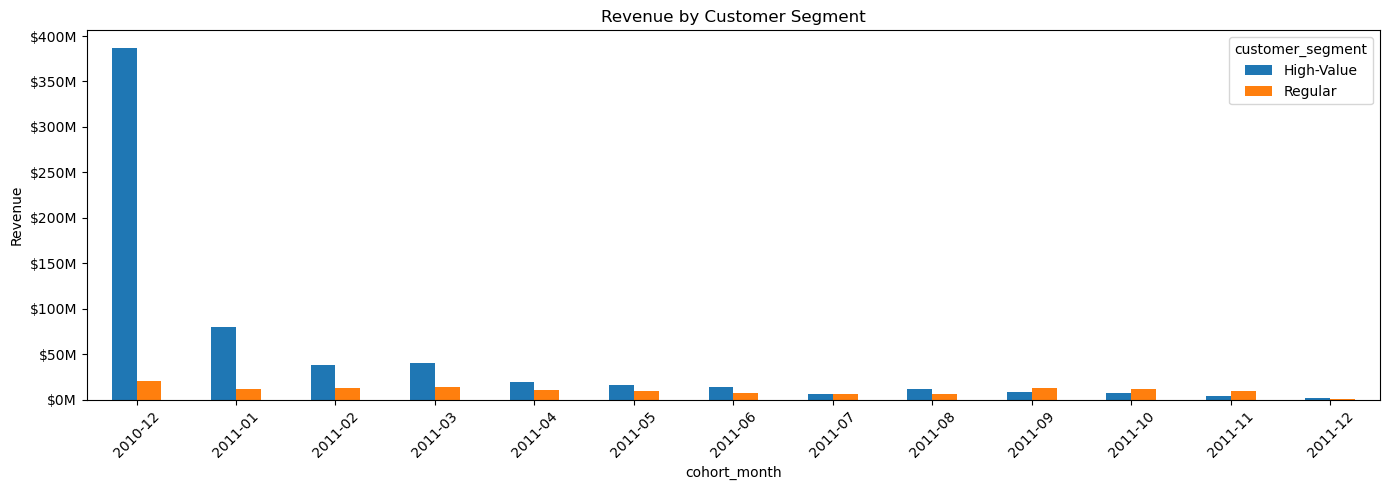

In [21]:
# Visualize revenue by customer segment

revenue_plot = revenue_by_customer_segment.reset_index()

revenue_plot.set_index('cohort_month')[['High-Value', 'Regular']].plot(
    kind='bar',
    figsize=(14, 5)
)

plt.title('Revenue by Customer Segment')
plt.ylabel('Revenue')

plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f'${int(y/1_000_000)}M')
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Revenue Contribution by Segment

- High-value customers generate the majority of total revenue
- Revenue distribution is highly skewed toward a small group of users

**Additional Observation:**
- The earliest cohort (2010-12) contributes a disproportionately large share of total revenue
- This cohort significantly exceeds all subsequent cohorts in revenue generation

**Insight:**  
While high-value users consistently drive revenue, the overall distribution is also heavily influenced by early cohorts.  

This suggests that:
- Early customer acquisition may have been of higher quality, OR
- The cohort had more time to generate cumulative revenue, OR
- There may be outliers (large buyers) concentrated in early cohorts

👉 Further investigation is needed to isolate cohort quality vs time effect.
Possible explanations:
- Longer lifetime → more accumulated revenue
- Different acquisition channels
- Presence of large B2B / bulk buyers
---

### Strategic Business Insights

**1. Revenue is highly concentrated among a small group of customers**
- Top ~30% of customers generate ~80%+ of total revenue
- Revenue follows a strong Pareto-like distribution

**Implication:**  
Business performance is heavily dependent on a small segment of high-value users.

**2. High-value customers drive all key metrics**
- Higher retention
- Higher AOV
- Disproportionately high revenue contribution

**Implication:**  
Not all customers are equal — a small segment generates the majority of long-term value.

**3. Weak early retention is the main growth bottleneck**
- ~70–80% of users churn after their first purchase

**Implication:**  
Improving early retention (Month 1–2) is the highest-impact opportunity for growth.

**4. Early lifecycle (Month 1–3) is critical**
- Most revenue is generated early
- Retention patterns are formed in the first months

**Implication:**  
Early engagement strategies (onboarding, offers, personalization) are key.

**5. Converting regular → high-value customers is the biggest opportunity**
- Regular users show low retention and low contribution
- High-value users exhibit strong long-term behavior

**Implication:**  
Growth should focus on identifying and nurturing potential high-value users.

**Final Insight:**  
The business is not driven by a broad loyal customer base, but by a small group of high-value repeat users.  
Maximizing growth requires:
- improving early retention
- identifying high-potential customers early
- and increasing the share of high-value users